1. [Cricket] Virat Kohli scored a brilliant century in the ODI match.
2. [Cricket] The bowler delivered a perfect yorker in the final over.
3. [Cricket] Cricket fans celebrated the thrilling last-ball victory.
4. [Cooking] I added chopped onions and tomatoes to the hot pan.
5. [Cooking] Baking a chocolate cake requires careful measurement of ingredients.
6. [Cooking] The chef seasoned the soup with pepper and fresh herbs.
7. [Cybersecurity] Strong passwords help protect accounts from cyber attacks.
8. [Cybersecurity] The company detected malware in its internal network.
9. [Cybersecurity] Phishing emails often trick users into sharing personal data.
10. [Cybersecurity] Firewall rules can reduce unauthorized access to systems.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

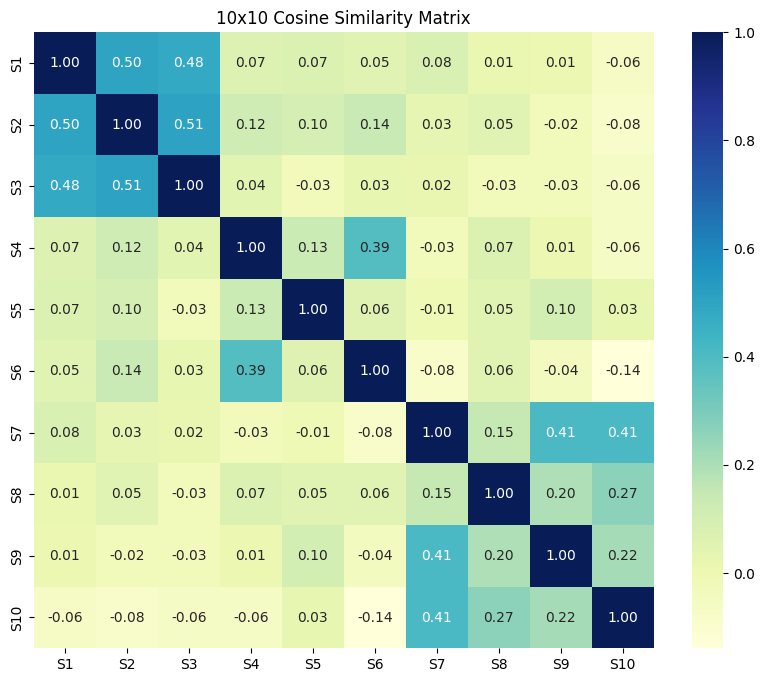

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The bowler delivered a perfect yorker in the final over.
Similarity Score: 0.6295

Sentence: Virat Kohli scored a brilliant century in the ODI match.
Similarity Score: 0.4576



In [1]:
!pip install sentence-transformers matplotlib seaborn scikit-learn -q
sentences = [
    "Virat Kohli scored a brilliant century in the ODI match.",
    "The bowler delivered a perfect yorker in the final over.",
    "Cricket fans celebrated the thrilling last-ball victory.",
    "I added chopped onions and tomatoes to the hot pan.",
    "Baking a chocolate cake requires careful measurement of ingredients.",
    "The chef seasoned the soup with pepper and fresh herbs.",
    "Strong passwords help protect accounts from cyber attacks.",
    "The company detected malware in its internal network.",
    "Phishing emails often trick users into sharing personal data.",
    "Firewall rules can reduce unauthorized access to systems."
]

topics = [
    "Cricket",
    "Cricket",
    "Cricket",
    "Cooking",
    "Cooking",
    "Cooking",
    "Cybersecurity",
    "Cybersecurity",
    "Cybersecurity",
    "Cybersecurity"
]

for i, s in enumerate(sentences, start=1):
    print(f"{i}. [{topics[i-1]}] {s}")
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

df_sim = pd.DataFrame(similarity_matrix, index=[f"S{i}" for i in range(1, 11)], columns=[f"S{i}" for i in range(1, 11)])
df_sim
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df_sim, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("10x10 Cosine Similarity Matrix")
plt.show()
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

query_similarities = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, query_similarities))
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print("Query:", query)
print("\nTop 2 most similar sentences:\n")
for sentence, score in results_sorted[:2]:
    print(f"Sentence: {sentence}")
    print(f"Similarity Score: {score:.4f}\n")
